In [ ]:
import marimo as mo
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import norm

In [ ]:
# Load data
train = pd.read_csv('data/polynomial_train-1.csv')
x_train, y_train = train['X'].to_numpy(), train['Y'].to_numpy()

test = pd.read_csv('data/polynomial_test-1.csv')
x_test, y_test = test['X'].to_numpy(), test['Y'].to_numpy()

In [ ]:
# Transform data
degree = 6
X_train = np.array([x_train] * degree).T
X_test = np.array([x_test] * degree).T

# Create polynomial variables
for i in range(degree):
    X_train[:,i] = X_train[:,i] ** i
    X_test[:, i] = X_test[:, i] ** i

# Q2: Regression with MAP

1. Analytical: Write out a mathematical expression for the MAP estimate
for the linear regression problem. Assume a gaussian prior for the weights,
$p(w) = N (w|w_0)$ as defined above. Write the expression such that it only
depends on the parameters we will estimate in this problem (Note: in this
part of the problem you don’t have actually find the maximum; just write
an expression of the likelihood that you could maximize)

The posterior is $p(w | X, y) \propto p(y | X, w) \cdot p(w)$. With Gaussian likelihood and prior $p(w) = \mathcal{N}(w | w_0, \sigma_0^2 I)$, the log-posterior is:

$$\log p(w | X, y) = -\frac{1}{2\sigma^2}\sum_{i=1}^{n}(y_i - x_i^T w)^2 - \frac{1}{2\sigma_0^2}\|w - w_0\|^2$$

2. Computational: Find the MAP numerically. You can use any optimization
process you’d like (hint: scipy.optimize and jax.scipy.optimize.minimize
are both straightforward). Show your code. Finally, plot the predicted
means using your MAP estimates on 1) the training data and 2) the test
data. (Hint: you may want to use the scipy.stats.norm class and its
associated methods).

In [ ]:
# Prior parameters
sigma = 1.0
w0 = np.zeros(degree)
sigma0 = 1.0

# Negative log-posterior (to minimize)
def neg_log_posterior(w: np.ndarray):
    residuals = y_train - X_train @ w
    log_likelihood = np.sum(norm.logpdf(residuals, loc=0, scale=sigma))
    log_prior = np.sum(norm.logpdf(w, loc=w0, scale=sigma0))
    return -(log_likelihood + log_prior)

result = minimize(neg_log_posterior, x0=np.zeros(degree))
betas_map = result.x

y_pred_map_train = X_train @ betas_map
y_pred_map_test = X_test @ betas_map

# Smooth curve for plotting
x_curve = np.linspace(min(np.min(x_train), np.min(x_test)), max(np.max(x_train), np.max(x_test)), 200)
X_curve = np.column_stack([x_curve**i for i in range(degree)])
X_curve_map = np.column_stack([x_curve**i for i in range(degree)])
y_curve_map = X_curve_map @ betas_map

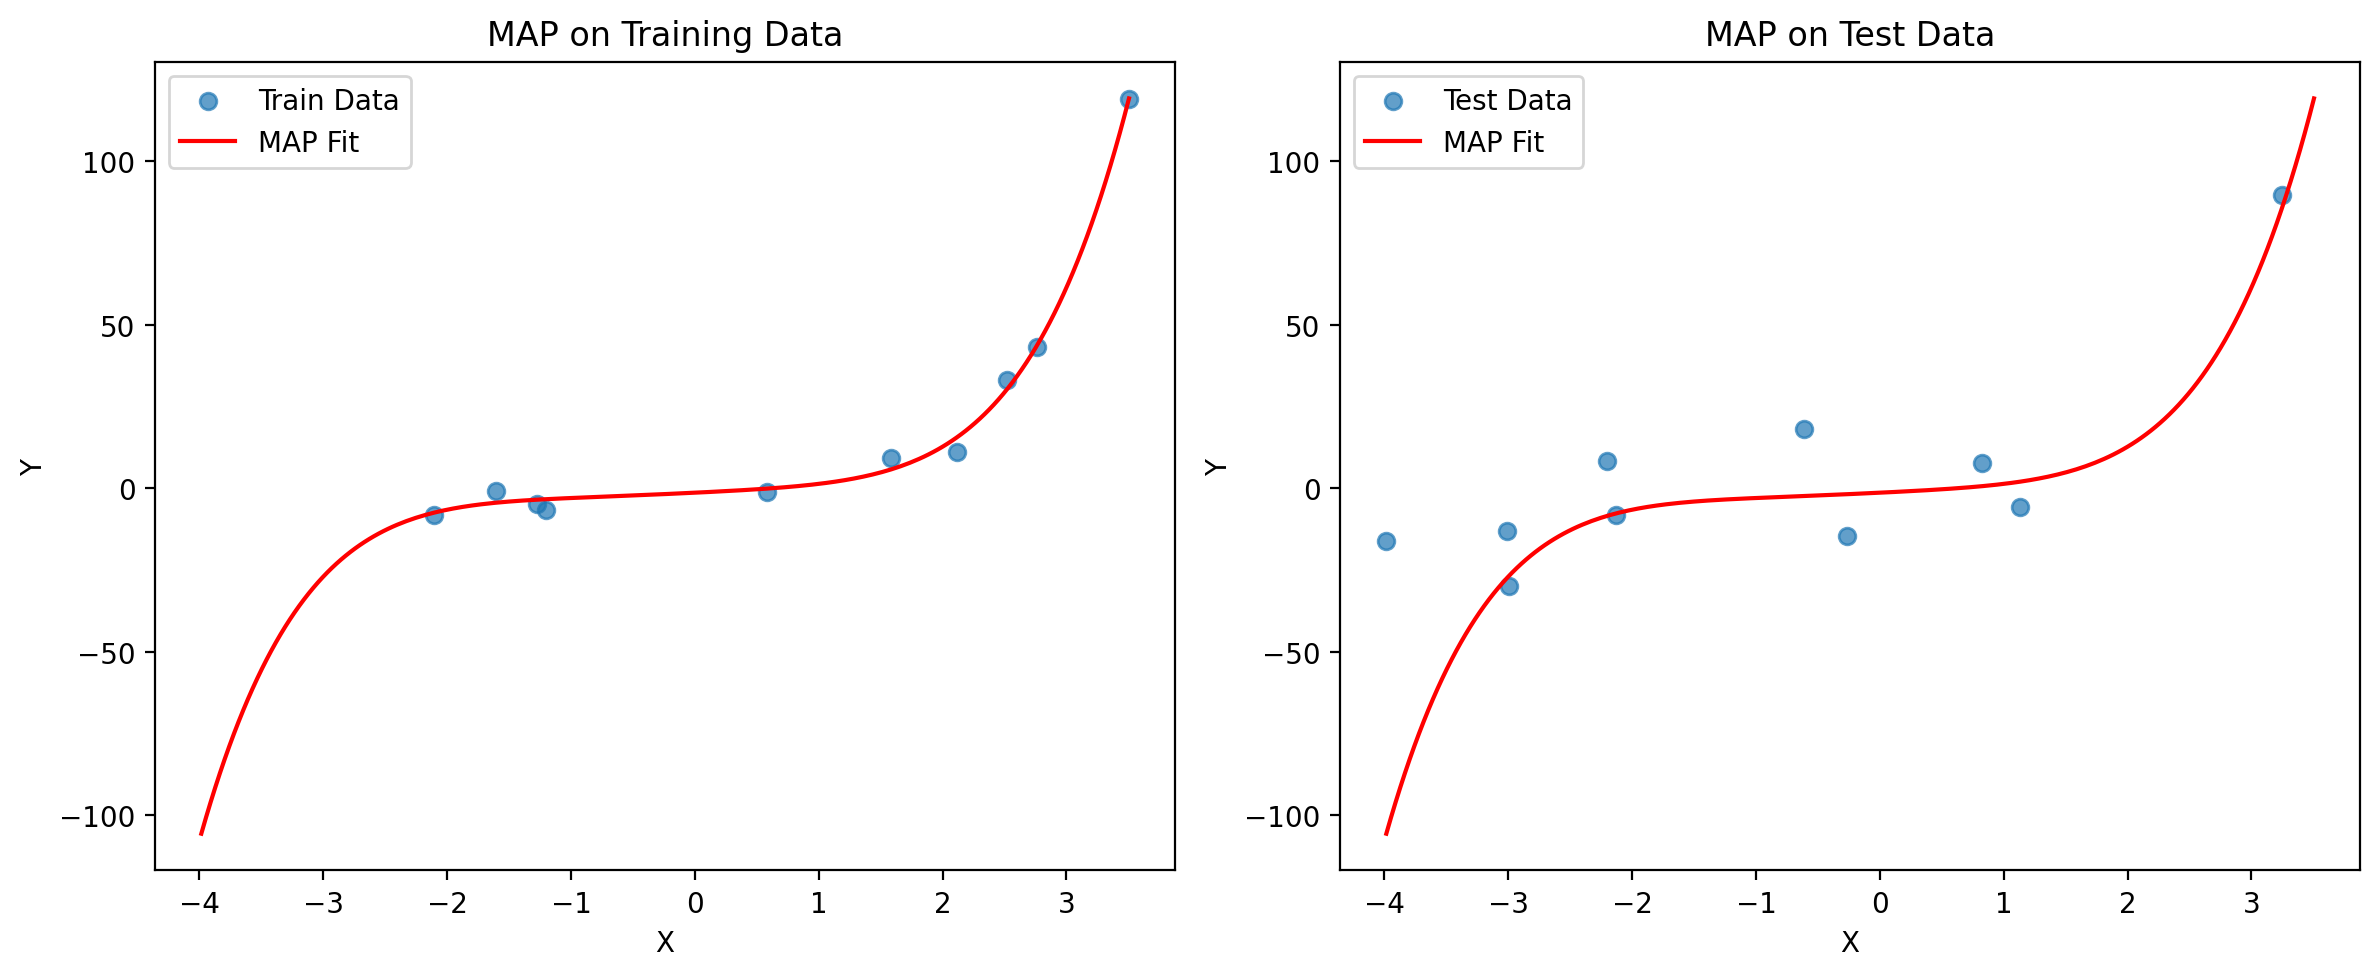

In [ ]:
_, axes_map = plt.subplots(1, 2, figsize=(12, 5))

axes_map[0].scatter(x_train, y_train, label="Train Data", alpha=0.7)
axes_map[0].plot(x_curve, y_curve_map, color='red', label="MAP Fit")
axes_map[0].set_xlabel("X")
axes_map[0].set_ylabel("Y")
axes_map[0].set_title("MAP on Training Data")
axes_map[0].legend()

axes_map[1].scatter(x_test, y_test, label="Test Data", alpha=0.7)
axes_map[1].plot(x_curve, y_curve_map, color='red', label="MAP Fit")
axes_map[1].set_xlabel("X")
axes_map[1].set_ylabel("Y")
axes_map[1].set_title("MAP on Test Data")
axes_map[1].legend()

plt.tight_layout()
plt.show()